## 1. Import Libraries and Load Dataset

In [ ]:
# Install required packages
!pip install torch scikit-learn pandas numpy matplotlib seaborn

In [ ]:
!pip install evaluate
!pip install datasets

In [ ]:
!pip install transformers -U

In [ ]:
!pip install accelerate

In [ ]:
!pip install --upgrade peft


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_auc_score,
    hamming_loss, jaccard_score, cohen_kappa_score, 
    matthews_corrcoef, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, 
    TrainingArguments, Trainer, EarlyStoppingCallback,
    DistilBertTokenizer, DistilBertForSequenceClassification,
    clinicalbertTokenizer, clinicalbertForSequenceClassification
)
import evaluate

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Using device: cuda


In [2]:
# Load the dataset
df = pd.read_csv('/kaggle/input/heart-disease-nlp/main_dataset.csv')

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nDataset info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())
print("\nLabel distribution:")
print(df['label'].value_counts())
print("\nLabel distribution (normalized):")
print(df['label'].value_counts(normalize=True))

Dataset shape: (1190, 2)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   patient_data  1190 non-null   object
 1   label         1190 non-null   object
dtypes: object(2)
memory usage: 18.7+ KB
None

First few rows:
                                        patient_data             label
0  The patient is a 40-year-old male who presente...  No heart Disease
1  The patient is a 49-year-old female who presen...     Heart Disease
2  The patient is a 37-year-old male who presente...  No heart Disease
3  The patient is a 48-year-old female who presen...     Heart Disease
4  The patient is a 54-year-old male who presente...  No heart Disease

Label distribution:
label
Heart Disease       629
No heart Disease    561
Name: count, dtype: int64

Label distribution (normalized):
label
Heart Disease       0.528571
No heart Disease    0.47142

## 2. Data Preprocessing and Text Cleaning

In [3]:
import re

def preprocess_text(text):
    """Clean and preprocess medical text data"""
    if pd.isna(text):
        return ""
    
    # Convert to string and strip whitespace
    text = str(text).strip()
    
    # Remove extra whitespaces and normalize spacing
    text = re.sub(r'\s+', ' ', text)
    
    # Remove excessive punctuation but keep medical terms
    text = re.sub(r'[-:;]{2,}', ' ', text)
    
    # Standardize medical abbreviations
    text = re.sub(r'\bmm\b', 'millimeters', text)
    text = re.sub(r'\bna\b', 'not_available', text)
    text = re.sub(r'\bnill\b', 'normal', text)
    
    return text

# Apply text preprocessing
df['cleaned_text'] = df['patient_data'].apply(preprocess_text)

# Create label encoder
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# Create label mapping for reference
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
reverse_label_mapping = {v: k for k, v in label_mapping.items()}

print("Label mapping:")
print(label_mapping)
print("\nReverse label mapping:")
print(reverse_label_mapping)

# Display sample processed text
print("\nSample processed text:")
for i in range(3):
    print(f"Original: {df.iloc[i]['patient_data'][:100]}...")
    print(f"Cleaned:  {df.iloc[i]['cleaned_text'][:100]}...")
    print(f"Label: {df.iloc[i]['label']} -> {df.iloc[i]['label_encoded']}")
    print("-" * 80)

Label mapping:
{'Heart Disease': np.int64(0), 'No heart Disease': np.int64(1)}

Reverse label mapping:
{np.int64(0): 'Heart Disease', np.int64(1): 'No heart Disease'}

Sample processed text:
Original: The patient is a 40-year-old male who presented for cardiovascular assessment. On examination, his r...
Cleaned:  The patient is a 40-year-old male who presented for cardiovascular assessment. On examination, his r...
Label: No heart Disease -> 1
--------------------------------------------------------------------------------
Original: The patient is a 49-year-old female who presented for a routine cardiovascular assessment. Despite b...
Cleaned:  The patient is a 49-year-old female who presented for a routine cardiovascular assessment. Despite b...
Label: Heart Disease -> 0
--------------------------------------------------------------------------------
Original: The patient is a 37-year-old male who presented with non-anginal chest pain for cardiovascular asses...
Cleaned:  The patient 

## 3. Dataset Balancing and Train-Test Split

In [9]:
# Balance the dataset using resampling
def balance_dataset(df, target_column='label_encoded', random_state=42):
    """Balance dataset using oversampling"""
    # Separate classes
    df_classes = []
    for label in df[target_column].unique():
        df_class = df[df[target_column] == label]
        df_classes.append(df_class)
    
    # Find the size of the largest class
    max_class_size = max([len(df_class) for df_class in df_classes])
    print(f"Max class size: {max_class_size}")
    
    # Resample each class to match the largest class
    balanced_dfs = []
    for df_class in df_classes:
        label_name = reverse_label_mapping[df_class[target_column].iloc[0]]
        if len(df_class) < max_class_size:
            # Oversample minority classes
            df_resampled = resample(
                df_class, 
                replace=True, 
                n_samples=max_class_size, 
                random_state=random_state
            )
            print(f"Oversampled {label_name}: {len(df_class)} -> {len(df_resampled)}")
        else:
            df_resampled = df_class
            print(f"Kept {label_name}: {len(df_class)}")
        balanced_dfs.append(df_resampled)
    
    # Combine all classes
    balanced_df = pd.concat(balanced_dfs, ignore_index=True)
    
    # Shuffle the dataset
    balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    return balanced_df

# Balance the dataset
print("Original label distribution:")
print(df['label_encoded'].value_counts().sort_index())
balanced_df = balance_dataset(df)
print("\nBalanced label distribution:")
print(balanced_df['label_encoded'].value_counts().sort_index())

# Create train, validation, and test splits (70/15/15 split)
train_val_df, test_df = train_test_split(
    balanced_df, 
    test_size=0.15,  # 15% for test
    random_state=42, 
    stratify=balanced_df['label_encoded']
)

train_df, val_df = train_test_split(
    train_val_df, 
    test_size=0.176,  # ~15% of total (0.15/0.85 ≈ 0.176) -> gives 70/15/15 split
    random_state=42, 
    stratify=train_val_df['label_encoded']
)

print(f"\nDataset splits:")
print(f"Training set: {len(train_df)} samples ({len(train_df)/len(balanced_df)*100:.1f}%)")
print(f"Validation set: {len(val_df)} samples ({len(val_df)/len(balanced_df)*100:.1f}%)")
print(f"Test set: {len(test_df)} samples ({len(test_df)/len(balanced_df)*100:.1f}%)")

# Verify stratification
print(f"\nTraining set label distribution:")
print(train_df['label_encoded'].value_counts().sort_index())
print(f"\nValidation set label distribution:")
print(val_df['label_encoded'].value_counts().sort_index())
print(f"\nTest set label distribution:")
print(test_df['label_encoded'].value_counts().sort_index())

Original label distribution:
label_encoded
0    629
1    561
Name: count, dtype: int64
Max class size: 629
Oversampled No heart Disease: 561 -> 629
Kept Heart Disease: 629

Balanced label distribution:
label_encoded
0    629
1    629
Name: count, dtype: int64

Dataset splits:
Training set: 880 samples (70.0%)
Validation set: 189 samples (15.0%)
Test set: 189 samples (15.0%)

Training set label distribution:
label_encoded
0    440
1    440
Name: count, dtype: int64

Validation set label distribution:
label_encoded
0    94
1    95
Name: count, dtype: int64

Test set label distribution:
label_encoded
0    95
1    94
Name: count, dtype: int64


## 4. Early Fusion Model Setup (Feature-level Fusion)

In [14]:
from datasets import Dataset
import torch.nn as nn

# Initialize tokenizers for both models
distilbert_model_name = "distilbert-base-uncased"
clinicalbert_model_name = "emilyalsentzer/Bio_ClinicalBERT"

distilbert_tokenizer = AutoTokenizer.from_pretrained(distilbert_model_name)
clinicalbert_tokenizer = AutoTokenizer.from_pretrained(clinicalbert_model_name)

num_labels = len(label_encoder.classes_)
print(f"Number of labels: {num_labels}")
print(f"Labels: {list(label_encoder.classes_)}")

# Early Fusion Model - Combines features from both DistilBERT and ClinicalBERT
class EarlyFusionModel(nn.Module):
    def __init__(self, num_labels):
        super(EarlyFusionModel, self).__init__()
        
        # Load pre-trained models (feature extractors)
        self.distilbert = AutoModelForSequenceClassification.from_pretrained(
            distilbert_model_name, num_labels=num_labels
        ).distilbert  # Use only the feature extractor part
        
        self.clinicalbert = AutoModelForSequenceClassification.from_pretrained(
            clinicalbert_model_name, num_labels=num_labels
        ).bert  # ClinicalBERT uses .bert attribute (not .clinicalbert)
        
        # Feature dimension from both models
        self.distilbert_hidden_size = self.distilbert.config.hidden_size  # 768
        self.clinicalbert_hidden_size = self.clinicalbert.config.hidden_size  # 768
        
        # Fusion layers
        self.feature_fusion = nn.Linear(
            self.distilbert_hidden_size + self.clinicalbert_hidden_size, 
            512
        )
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(512, num_labels)
        self.relu = nn.ReLU()
        
    def forward(self, bert_input_ids, bert_attention_mask, 
                clinicalbert_input_ids, clinicalbert_attention_mask, labels=None):
        
        # Get features from DistilBERT
        bert_outputs = self.distilbert(
            input_ids=bert_input_ids,
            attention_mask=bert_attention_mask
        )
        bert_features = bert_outputs.last_hidden_state[:, 0, :]  # [CLS] token
        
        # Get features from ClinicalBERT  
        clinicalbert_outputs = self.clinicalbert(
            input_ids=clinicalbert_input_ids,
            attention_mask=clinicalbert_attention_mask
        )
        clinicalbert_features = clinicalbert_outputs.last_hidden_state[:, 0, :]  # [CLS] token
        
        # Concatenate features (Early Fusion)
        fused_features = torch.cat([bert_features, clinicalbert_features], dim=1)
        
        # Process fused features
        fused_features = self.feature_fusion(fused_features)
        fused_features = self.relu(fused_features)
        fused_features = self.dropout(fused_features)
        
        # Final classification
        logits = self.classifier(fused_features)
        
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, num_labels), labels.view(-1))
        
        return type('obj', (object,), {'loss': loss, 'logits': logits})()

# Custom Dataset for Early Fusion (needs both tokenizers)
class EarlyFusionDataset(Dataset):
    def __init__(self, texts, labels, bert_tokenizer, clinicalbert_tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.bert_tokenizer = bert_tokenizer
        self.clinicalbert_tokenizer = clinicalbert_tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        
        # Tokenize with DistilBERT tokenizer
        bert_encoding = self.bert_tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        # Tokenize with ClinicalBERT tokenizer
        clinicalbert_encoding = self.clinicalbert_tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'bert_input_ids': bert_encoding['input_ids'].flatten(),
            'bert_attention_mask': bert_encoding['attention_mask'].flatten(),
            'clinicalbert_input_ids': clinicalbert_encoding['input_ids'].flatten(),
            'clinicalbert_attention_mask': clinicalbert_encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create Early Fusion datasets
train_dataset_early = EarlyFusionDataset(
    train_df['cleaned_text'].tolist(),
    train_df['label_encoded'].tolist(),
    distilbert_tokenizer,
    clinicalbert_tokenizer
)

val_dataset_early = EarlyFusionDataset(
    val_df['cleaned_text'].tolist(),
    val_df['label_encoded'].tolist(),
    distilbert_tokenizer,
    clinicalbert_tokenizer
)

test_dataset_early = EarlyFusionDataset(
    test_df['cleaned_text'].tolist(),
    test_df['label_encoded'].tolist(),
    distilbert_tokenizer,
    clinicalbert_tokenizer
)

print(f"Early Fusion datasets created:")
print(f"Train: {len(train_dataset_early)} samples")
print(f"Validation: {len(val_dataset_early)} samples")
print(f"Test: {len(test_dataset_early)} samples")

Number of labels: 2
Labels: ['Heart Disease', 'No heart Disease']
Early Fusion datasets created:
Train: 880 samples
Validation: 189 samples
Test: 189 samples


## 5. Late Fusion Model Setup (Decision-level Fusion)

In [15]:
# Late Fusion Model - Separate models with decision-level fusion
class LateFusionModel(nn.Module):
    def __init__(self, num_labels):
        super(LateFusionModel, self).__init__()
        
        # Separate complete models for each architecture
        self.distilbert_model = AutoModelForSequenceClassification.from_pretrained(
            distilbert_model_name, num_labels=num_labels
        )
        
        self.clinicalbert_model = AutoModelForSequenceClassification.from_pretrained(
            clinicalbert_model_name, num_labels=num_labels
        )
        
        # Decision fusion layers
        self.fusion_layer = nn.Linear(num_labels * 2, num_labels)  # Combine 2 predictions
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, bert_input_ids, bert_attention_mask, 
                clinicalbert_input_ids, clinicalbert_attention_mask, labels=None):
        
        # Get predictions from DistilBERT
        bert_outputs = self.distilbert_model(
            input_ids=bert_input_ids,
            attention_mask=bert_attention_mask
        )
        bert_logits = bert_outputs.logits
        
        # Get predictions from ClinicalBERT
        clinicalbert_outputs = self.clinicalbert_model(
            input_ids=clinicalbert_input_ids,
            attention_mask=clinicalbert_attention_mask
        )
        clinicalbert_logits = clinicalbert_outputs.logits
        
        # Combine predictions (Late Fusion at decision level)
        combined_logits = torch.cat([bert_logits, clinicalbert_logits], dim=1)
        combined_logits = self.dropout(combined_logits)
        final_logits = self.fusion_layer(combined_logits)
        
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(final_logits.view(-1, num_labels), labels.view(-1))
        
        return type('obj', (object,), {'loss': loss, 'logits': final_logits})()

# For individual model training in Late Fusion approach, create standard datasets
def tokenize_function_bert(examples):
    return distilbert_tokenizer(
        examples['cleaned_text'], 
        truncation=True, 
        padding='max_length', 
        max_length=512
    )

def tokenize_function_clinicalbert(examples):
    return clinicalbert_tokenizer(
        examples['cleaned_text'], 
        truncation=True, 
        padding='max_length', 
        max_length=512
    )

# Create datasets for individual models (for Late Fusion training)
# DistilBERT datasets
train_dataset_bert = Dataset.from_pandas(train_df[['cleaned_text', 'label_encoded']])
val_dataset_bert = Dataset.from_pandas(val_df[['cleaned_text', 'label_encoded']])
test_dataset_bert = Dataset.from_pandas(test_df[['cleaned_text', 'label_encoded']])

train_dataset_bert = train_dataset_bert.map(tokenize_function_bert, batched=True)
val_dataset_bert = val_dataset_bert.map(tokenize_function_bert, batched=True)
test_dataset_bert = test_dataset_bert.map(tokenize_function_bert, batched=True)

train_dataset_bert = train_dataset_bert.rename_column("label_encoded", "labels")
val_dataset_bert = val_dataset_bert.rename_column("label_encoded", "labels")
test_dataset_bert = test_dataset_bert.rename_column("label_encoded", "labels")

train_dataset_bert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset_bert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset_bert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# ClinicalBERT datasets  
train_dataset_clinicalbert = Dataset.from_pandas(train_df[['cleaned_text', 'label_encoded']])
val_dataset_clinicalbert = Dataset.from_pandas(val_df[['cleaned_text', 'label_encoded']])
test_dataset_clinicalbert = Dataset.from_pandas(test_df[['cleaned_text', 'label_encoded']])

train_dataset_clinicalbert = train_dataset_clinicalbert.map(tokenize_function_clinicalbert, batched=True)
val_dataset_clinicalbert = val_dataset_clinicalbert.map(tokenize_function_clinicalbert, batched=True)
test_dataset_clinicalbert = test_dataset_clinicalbert.map(tokenize_function_clinicalbert, batched=True)

train_dataset_clinicalbert = train_dataset_clinicalbert.rename_column("label_encoded", "labels")
val_dataset_clinicalbert = val_dataset_clinicalbert.rename_column("label_encoded", "labels")
test_dataset_clinicalbert = test_dataset_clinicalbert.rename_column("label_encoded", "labels")

train_dataset_clinicalbert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset_clinicalbert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset_clinicalbert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print(f"Late Fusion individual model datasets created:")
print(f"DistilBERT - Train: {len(train_dataset_bert)}, Val: {len(val_dataset_bert)}, Test: {len(test_dataset_bert)}")
print(f"ClinicalBERT - Train: {len(train_dataset_clinicalbert)}, Val: {len(val_dataset_clinicalbert)}, Test: {len(test_dataset_clinicalbert)}")

print("Late Fusion model architecture created with decision-level fusion")

Map:   0%|          | 0/880 [00:00<?, ? examples/s]

Map:   0%|          | 0/189 [00:00<?, ? examples/s]

Map:   0%|          | 0/189 [00:00<?, ? examples/s]

Map:   0%|          | 0/880 [00:00<?, ? examples/s]

Map:   0%|          | 0/189 [00:00<?, ? examples/s]

Map:   0%|          | 0/189 [00:00<?, ? examples/s]

Late Fusion individual model datasets created:
DistilBERT - Train: 880, Val: 189, Test: 189
ClinicalBERT - Train: 880, Val: 189, Test: 189
Late Fusion model architecture created with decision-level fusion


## 6. Model Training and Validation

In [16]:
# Training function with comprehensive metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    # Calculate basic metrics
    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='weighted', zero_division=0)
    recall = recall_score(labels, predictions, average='weighted', zero_division=0)
    f1 = f1_score(labels, predictions, average='weighted', zero_division=0)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    seed=42,
    fp16=torch.cuda.is_available(),
)

print("Training arguments configured")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments configured


In [17]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

# Fixed Early Fusion Dataset Class - Simple approach
class EarlyFusionDataset(Dataset):
    def __init__(self, texts, labels, bert_tokenizer, clinicalbert_tokenizer, max_length=512):
        self.texts = list(texts) if not isinstance(texts, list) else texts
        self.labels = list(labels) if not isinstance(labels, list) else labels
        self.bert_tokenizer = bert_tokenizer
        self.clinicalbert_tokenizer = clinicalbert_tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        if isinstance(idx, (list, tuple)):
            idx = idx[0] if len(idx) > 0 else 0
            
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        
        bert_encoding = self.bert_tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        clinicalbert_encoding = self.clinicalbert_tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'bert_input_ids': bert_encoding['input_ids'].squeeze(0),
            'bert_attention_mask': bert_encoding['attention_mask'].squeeze(0),
            'clinicalbert_input_ids': clinicalbert_encoding['input_ids'].squeeze(0),
            'clinicalbert_attention_mask': clinicalbert_encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Simple collate function
def simple_collate_fn(batch):
    if len(batch) == 0:
        return {}
    
    return {
        'bert_input_ids': torch.stack([item['bert_input_ids'] for item in batch]),
        'bert_attention_mask': torch.stack([item['bert_attention_mask'] for item in batch]),
        'clinicalbert_input_ids': torch.stack([item['clinicalbert_input_ids'] for item in batch]),
        'clinicalbert_attention_mask': torch.stack([item['clinicalbert_attention_mask'] for item in batch]),
        'labels': torch.stack([item['labels'] for item in batch])
    }

# Clean Table Format Trainer
class CleanTableTrainer:
    def __init__(self, model, train_dataset, val_dataset, device, num_epochs=100, batch_size=32, lr=1e-5):
        self.model = model.to(device)
        self.device = device
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.lr = lr
        
        self.optimizer = torch.optim.AdamW(
            self.model.parameters(), 
            lr=lr, 
            weight_decay=0.01
        )
        
        self.criterion = nn.CrossEntropyLoss()
        
        self.train_loader = DataLoader(
            train_dataset, 
            batch_size=batch_size, 
            shuffle=True,
            collate_fn=simple_collate_fn,
            num_workers=0,
            pin_memory=False
        )
        
        self.val_loader = DataLoader(
            val_dataset, 
            batch_size=batch_size,
            shuffle=False,
            collate_fn=simple_collate_fn,
            num_workers=0,
            pin_memory=False
        )
        
        # Store training history
        self.history = []
        
        print(f"✅ Trainer initialized")
        print(f"   Train batches: {len(self.train_loader)}, Val batches: {len(self.val_loader)}")
        
    def train_epoch(self):
        """Train for one epoch and return average loss and accuracy"""
        self.model.train()
        total_loss = 0
        correct_predictions = 0
        total_samples = 0
        
        for batch in self.train_loader:
            self.optimizer.zero_grad()
            
            bert_input_ids = batch['bert_input_ids'].to(self.device)
            bert_attention_mask = batch['bert_attention_mask'].to(self.device)
            clinicalbert_input_ids = batch['clinicalbert_input_ids'].to(self.device)
            clinicalbert_attention_mask = batch['clinicalbert_attention_mask'].to(self.device)
            labels = batch['labels'].to(self.device)
            
            outputs = self.model(
                bert_input_ids=bert_input_ids,
                bert_attention_mask=bert_attention_mask,
                clinicalbert_input_ids=clinicalbert_input_ids,
                clinicalbert_attention_mask=clinicalbert_attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            
            total_loss += loss.item()
            predictions = torch.argmax(outputs.logits, dim=1)
            correct_predictions += (predictions == labels).sum().item()
            total_samples += labels.size(0)
        
        avg_loss = total_loss / len(self.train_loader)
        accuracy = correct_predictions / total_samples
        return avg_loss, accuracy
    
    def evaluate(self):
        """Evaluate on validation set and return loss and accuracy"""
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for batch in self.val_loader:
                bert_input_ids = batch['bert_input_ids'].to(self.device)
                bert_attention_mask = batch['bert_attention_mask'].to(self.device)
                clinicalbert_input_ids = batch['clinicalbert_input_ids'].to(self.device)
                clinicalbert_attention_mask = batch['clinicalbert_attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(
                    bert_input_ids=bert_input_ids,
                    bert_attention_mask=bert_attention_mask,
                    clinicalbert_input_ids=clinicalbert_input_ids,
                    clinicalbert_attention_mask=clinicalbert_attention_mask,
                    labels=labels
                )
                
                loss = outputs.loss
                total_loss += loss.item()
                
                predictions = torch.argmax(outputs.logits, dim=1)
                total += labels.size(0)
                correct += (predictions == labels).sum().item()
        
        avg_loss = total_loss / len(self.val_loader)
        accuracy = correct / total if total > 0 else 0.0
        return avg_loss, accuracy
    
    def train(self):
        """Train the model and display results in table format"""
        print("\n🚀 Starting training with 100 epochs...")
        print("="*70)
        
        # Print table header
        print(f"\n{'Epoch':<8}{'Training Loss':<18}{'Validation Loss':<20}{'Accuracy':<12}")
        print("-" * 58)
        
        try:
            for epoch in range(self.num_epochs):
                # Train for one epoch
                train_loss, train_acc = self.train_epoch()
                
                # Evaluate on validation set
                val_loss, val_acc = self.evaluate()
                
                # Store history
                self.history.append({
                    'epoch': epoch + 1,
                    'train_loss': train_loss,
                    'val_loss': val_loss,
                    'val_acc': val_acc
                })
                
                # Print results in table format
                print(f"{epoch+1:<8}{train_loss:<18.6f}{val_loss:<20.6f}{val_acc:<12.6f}")
                
        except KeyboardInterrupt:
            print("\n\n Training interrupted by user")
        except Exception as e:
            print(f"\n Error during training: {e}")
            import traceback
            traceback.print_exc()
        
        print("\n" + "="*70)
        print(" Training completed!")
        return self.history

# Create datasets
print("🔄 Creating Early Fusion datasets...")

train_texts = list(train_df['cleaned_text'])
train_labels = list(train_df['label_encoded'])
val_texts = list(val_df['cleaned_text'])
val_labels = list(val_df['label_encoded'])
test_texts = list(test_df['cleaned_text'])
test_labels = list(test_df['label_encoded'])

train_dataset = EarlyFusionDataset(
    train_texts, train_labels, distilbert_tokenizer, clinicalbert_tokenizer
)
val_dataset = EarlyFusionDataset(
    val_texts, val_labels, distilbert_tokenizer, clinicalbert_tokenizer
)
test_dataset = EarlyFusionDataset(
    test_texts, test_labels, distilbert_tokenizer, clinicalbert_tokenizer
)

print(f" Datasets created: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

# Train the model
print("\n Training Early Fusion Model...")

try:
    # Create fresh model instance
    early_fusion_model = EarlyFusionModel(num_labels)
    
    # Create trainer with 100 epochs and batch size 32
    trainer = CleanTableTrainer(
        model=early_fusion_model,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        device=device,
        num_epochs=50,
        batch_size=16,
        lr=1e-5
    )
    
    # Start training
    history = trainer.train()
    
    # Save the model
    torch.save(early_fusion_model.state_dict(), "./early_fusion_model.pth")
    print("\n Model saved to './early_fusion_model.pth'")
    
    # Save complete info
    torch.save({
        'model_state_dict': early_fusion_model.state_dict(),
        'num_labels': num_labels,
        'label_encoder': label_encoder,
        'model_type': 'EarlyFusionModel',
        'history': history
    }, "./early_fusion_complete.pth")
    print(" Complete model info saved to './early_fusion_complete.pth'")
    
except Exception as e:
    print(f" Training failed: {e}")
    import traceback
    traceback.print_exc()

print("\n Training process completed!")

🔄 Creating Early Fusion datasets...
 Datasets created: Train=880, Val=189, Test=189

 Training Early Fusion Model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

✅ Trainer initialized
   Train batches: 55, Val batches: 12

🚀 Starting training with 100 epochs...

Epoch   Training Loss     Validation Loss     Accuracy    
----------------------------------------------------------
1       0.624544          0.520841            0.746032    
2       0.427224          0.442963            0.825397    
3       0.369553          0.415152            0.841270    
4       0.300963          0.402486            0.846561    
5       0.249287          0.394127            0.873016    
6       0.195430          0.415243            0.873016    
7       0.155635          0.463969            0.873016    
8       0.104884          0.436316            0.878307    
9       0.091262          0.471987            0.888889    
10      0.074487          0.529157            0.873016    
11      0.065604          0.460428            0.899471    
12      0.053882          0.570247            0.873016    
13      0.037098          0.696479            0.883598    
14      0.0205

In [18]:
import torch
from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
import time

# ========== GPU Setup and Verification ==========
print("=" * 60)
print("DEVICE SETUP")
print("=" * 60)

# Detect and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")

if torch.cuda.is_available():
    print(f"✓ GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"✓ CUDA Version: {torch.version.cuda}")
    # Clear GPU cache
    torch.cuda.empty_cache()
    print("✓ GPU cache cleared")
else:
    print("⚠ WARNING: GPU not available! Training will be slow on CPU.")

print("=" * 60)
print()

# ========== Train Individual Models for Late Fusion ==========
print("=" * 60)
print("TRAINING INDIVIDUAL MODELS FOR LATE FUSION")
print("=" * 60)
print()

# Training arguments with progress reporting
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=50,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,  # Log every 50 steps
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    seed=42,
    report_to="none",  # Disable wandb/tensorboard if not needed
    disable_tqdm=False,  # Enable progress bars
    fp16=torch.cuda.is_available(),  # Use mixed precision on GPU
)

# ========== Train DistilBERT Model ==========
print("─" * 60)
print("MODEL 1/2: TRAINING DISTILBERT")
print("─" * 60)
start_time = time.time()

print(f"Loading DistilBERT model: {distilbert_model_name}")
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    distilbert_model_name,
    num_labels=num_labels
).to(device)

# Verify model is on GPU
print(f"✓ Model device: {next(distilbert_model.parameters()).device}")
print(f"✓ Model parameters: {sum(p.numel() for p in distilbert_model.parameters()):,}")
print(f"✓ Trainable parameters: {sum(p.numel() for p in distilbert_model.parameters() if p.requires_grad):,}")

if torch.cuda.is_available():
    print(f"✓ GPU Memory before training: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")

print("\nStarting DistilBERT training...")
distilbert_trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=train_dataset_bert,
    eval_dataset=val_dataset_bert,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

distilbert_trainer.train()

elapsed_time = time.time() - start_time
print(f"\n✓ DistilBERT training completed in {elapsed_time/60:.2f} minutes!")

if torch.cuda.is_available():
    print(f"✓ Peak GPU Memory: {torch.cuda.max_memory_allocated(0) / 1e9:.2f} GB")
    torch.cuda.empty_cache()
    print("✓ GPU cache cleared")

print()

# ========== Train clinicalbert Model ==========
print("─" * 60)
print("MODEL 2/2: TRAINING clinicalbert")
print("─" * 60)
start_time = time.time()

print(f"Loading clinicalbert model: {clinicalbert_model_name}")
clinicalbert_model = AutoModelForSequenceClassification.from_pretrained(
    clinicalbert_model_name,
    num_labels=num_labels
).to(device)

# Verify model is on GPU
print(f"✓ Model device: {next(clinicalbert_model.parameters()).device}")
print(f"✓ Model parameters: {sum(p.numel() for p in clinicalbert_model.parameters()):,}")
print(f"✓ Trainable parameters: {sum(p.numel() for p in clinicalbert_model.parameters() if p.requires_grad):,}")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    print(f"✓ GPU Memory before training: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")

print("\nStarting clinicalbert training...")
clinicalbert_trainer = Trainer(
    model=clinicalbert_model,
    args=training_args,
    train_dataset=train_dataset_clinicalbert,
    eval_dataset=val_dataset_clinicalbert,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

clinicalbert_trainer.train()

elapsed_time = time.time() - start_time
print(f"\n✓ clinicalbert training completed in {elapsed_time/60:.2f} minutes!")

if torch.cuda.is_available():
    print(f"✓ Peak GPU Memory: {torch.cuda.max_memory_allocated(0) / 1e9:.2f} GB")
    torch.cuda.empty_cache()
    print("✓ GPU cache cleared")

print()

# ========== Save Models ==========
print("─" * 60)
print("SAVING MODELS")
print("─" * 60)

print("Saving DistilBERT model...")
distilbert_trainer.save_model("./distilbert_individual")
distilbert_tokenizer.save_pretrained("./distilbert_individual")
print("✓ DistilBERT saved to ./distilbert_individual")

print("Saving clinicalbert model...")
clinicalbert_trainer.save_model("./clinicalbert_individual")
clinicalbert_tokenizer.save_pretrained("./clinicalbert_individual")
print("✓ clinicalbert saved to ./clinicalbert_individual")

print()
print("=" * 60)
print("✓ ALL INDIVIDUAL MODELS TRAINED AND SAVED FOR LATE FUSION!")
print("=" * 60)

# ========== Print Final GPU Stats ==========
if torch.cuda.is_available():
    print(f"\nFinal GPU Memory: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")

DEVICE SETUP
✓ Device: cuda
✓ GPU Name: Tesla P100-PCIE-16GB
✓ GPU Memory: 17.06 GB
✓ CUDA Version: 12.6


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✓ GPU cache cleared

TRAINING INDIVIDUAL MODELS FOR LATE FUSION

────────────────────────────────────────────────────────────
MODEL 1/2: TRAINING DISTILBERT
────────────────────────────────────────────────────────────
Loading DistilBERT model: distilbert-base-uncased


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...


✓ clinicalbert training completed in 8.37 minutes!
✓ Peak GPU Memory: 6.86 GB
✓ GPU cache cleared

────────────────────────────────────────────────────────────
SAVING MODELS
────────────────────────────────────────────────────────────
Saving DistilBERT model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ DistilBERT saved to ./distilbert_individual
Saving clinicalbert model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ clinicalbert saved to ./clinicalbert_individual

✓ ALL INDIVIDUAL MODELS TRAINED AND SAVED FOR LATE FUSION!

Final GPU Memory: 4.95 GB


## 7. Comprehensive Model Evaluation

COMPREHENSIVE MODEL EVALUATION - EARLY FUSION vs LATE FUSION

📋 Dataset Info:
   Number of classes: 2
   Classes: Heart Disease, No heart Disease
   Validation samples: 189

1. EVALUATING EARLY FUSION MODEL
Evaluating Early Fusion model...
  Processed 10/12 batches
✅ Early Fusion evaluation complete!

2. LOADING LATE FUSION MODELS
📥 Loading trained individual models...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Models loaded successfully!

3. EVALUATING LATE FUSION - PROBABILITY AVERAGING
Evaluating Late Fusion model (average)...
  Getting DistilBERT predictions...
  Getting ClinicalBERT predictions...
✅ Late Fusion (Averaging) evaluation complete!

4. EVALUATING LATE FUSION - MAJORITY VOTING
Evaluating Late Fusion model (voting)...
  Getting DistilBERT predictions...
  Getting ClinicalBERT predictions...
✅ Late Fusion (Voting) evaluation complete!

5. EVALUATING INDIVIDUAL MODELS (FOR REFERENCE)
  Evaluating DistilBERT...
  Evaluating ClinicalBERT...
✅ Individual models evaluation complete!

COMPREHENSIVE METRICS COMPARISON


                    Model  Accuracy  F1 (Weighted)  Precision (Weighted)  Recall (Weighted)  Cohen's Kappa  Matthews Corr Coeff
             Early Fusion    0.8995         0.8995                0.8999             0.8995         0.7990               0.7994
  Late Fusion (Averaging)    0.9101         0.9100                0.9112             0.9101         0.8202        

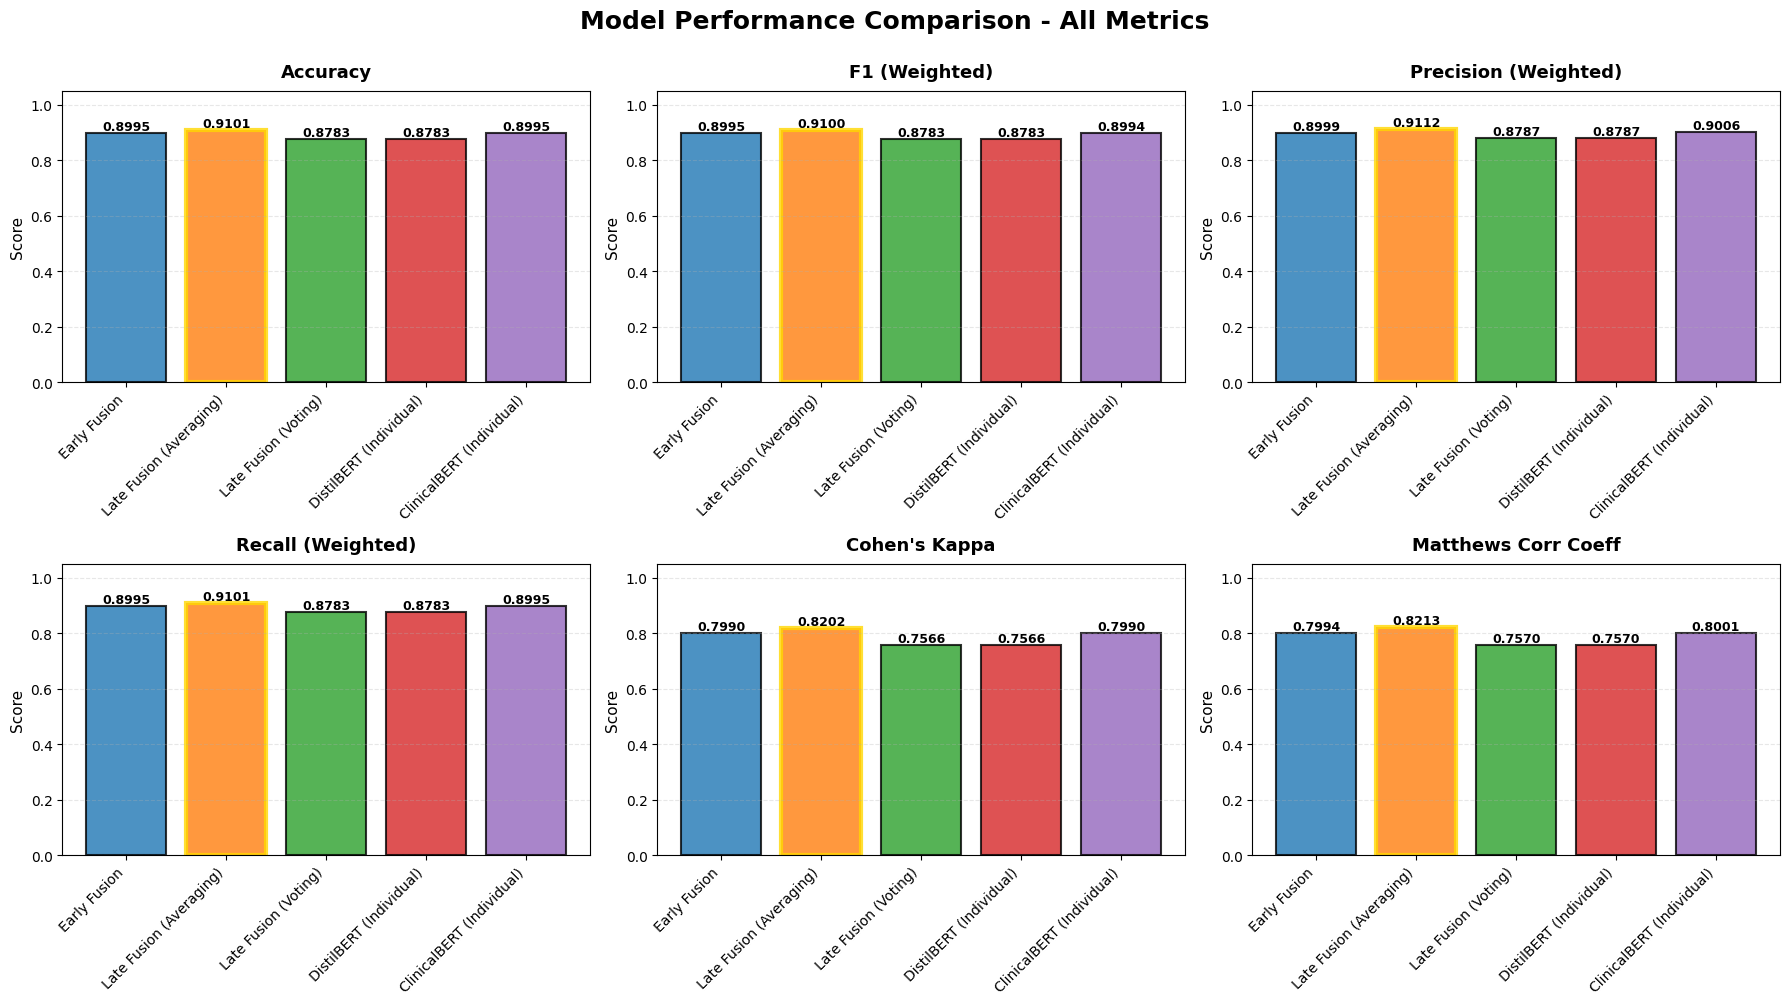


📊 Generating confusion matrices for all models...

  → Plotting Early Fusion confusion matrix...


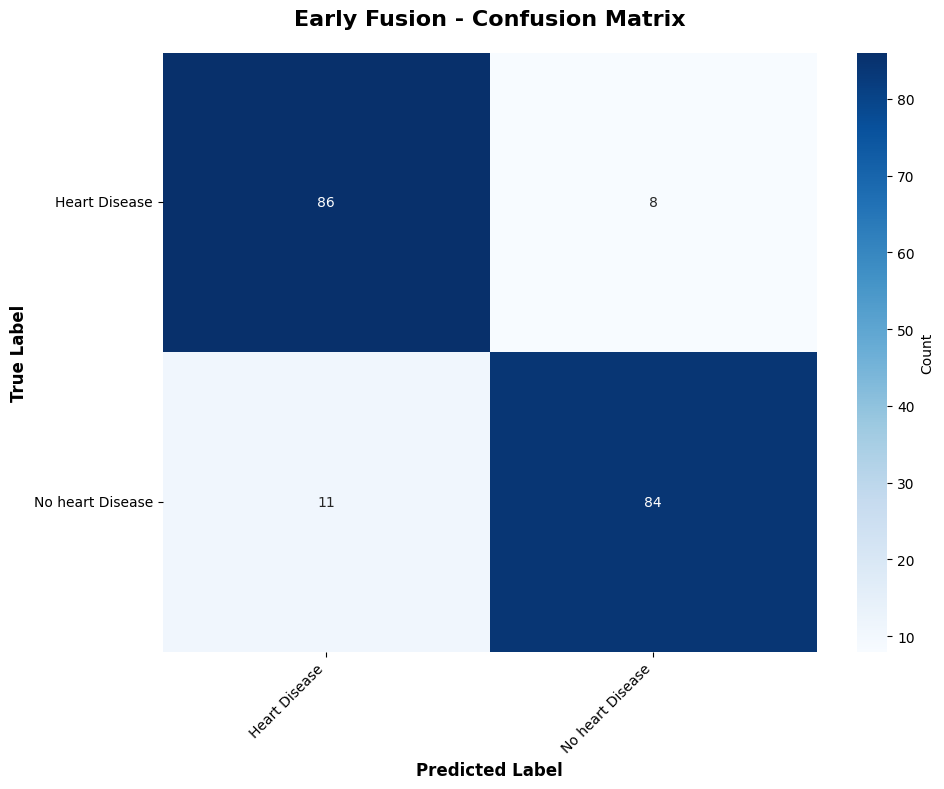

  → Plotting Late Fusion (Averaging) confusion matrix...


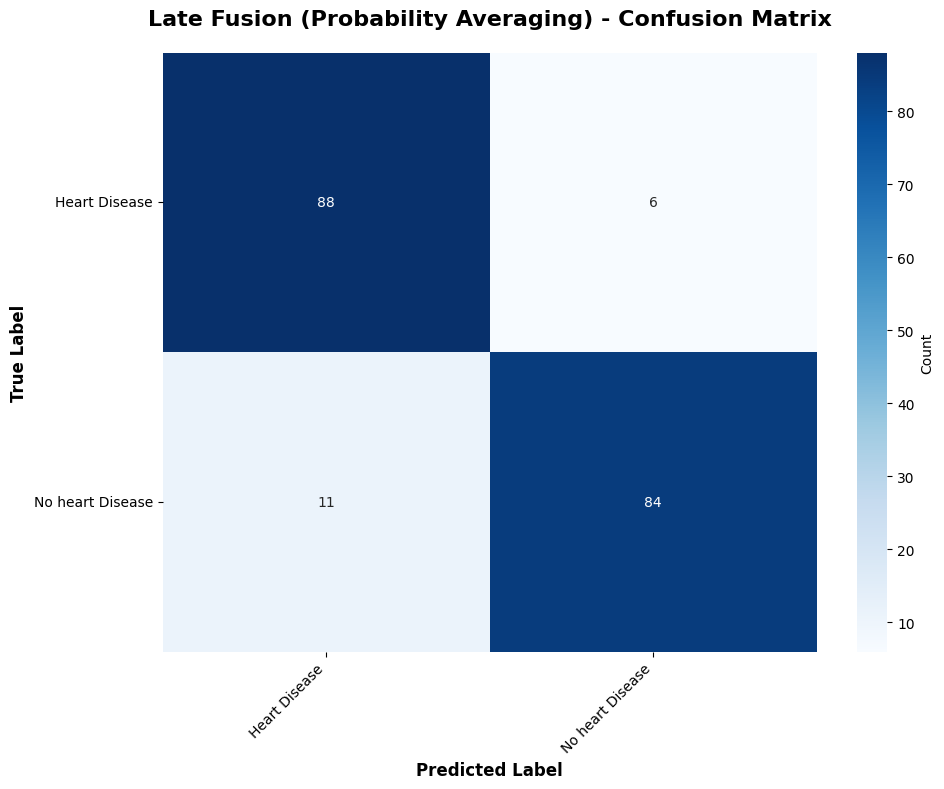

  → Plotting Late Fusion (Voting) confusion matrix...


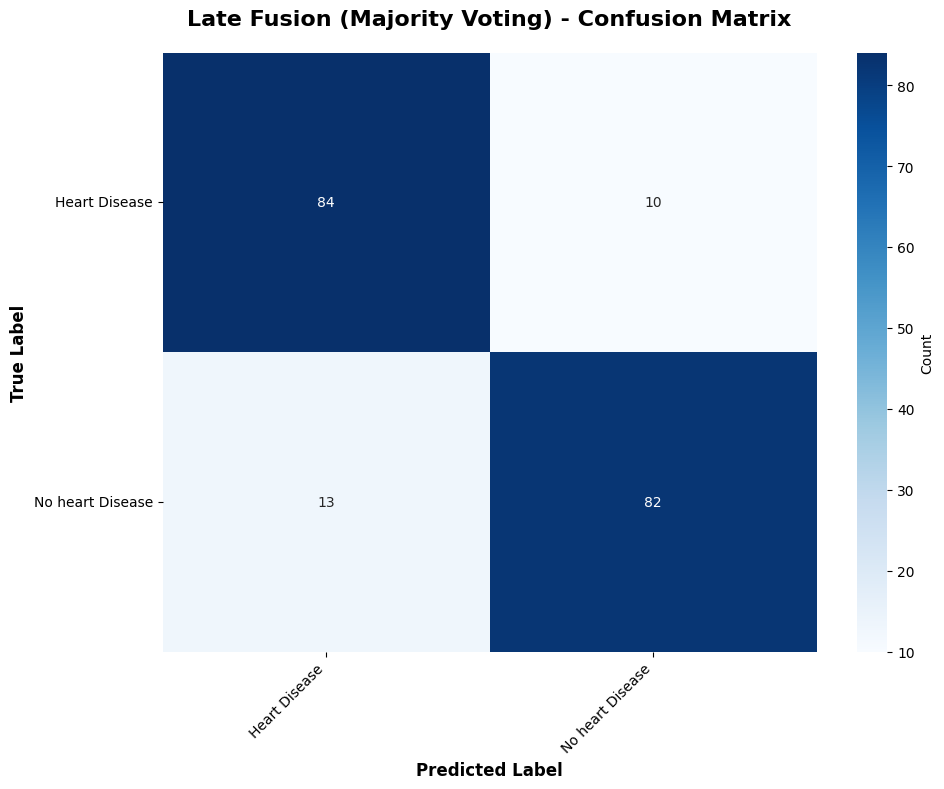

  → Plotting DistilBERT (Individual) confusion matrix...


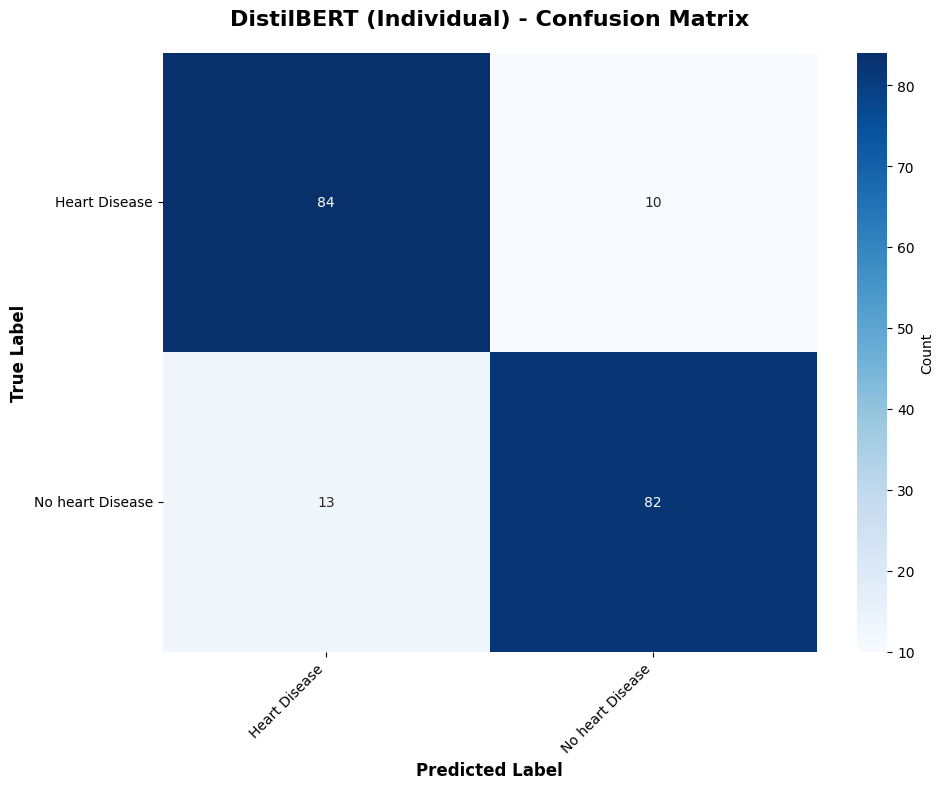

  → Plotting ClinicalBERT (Individual) confusion matrix...


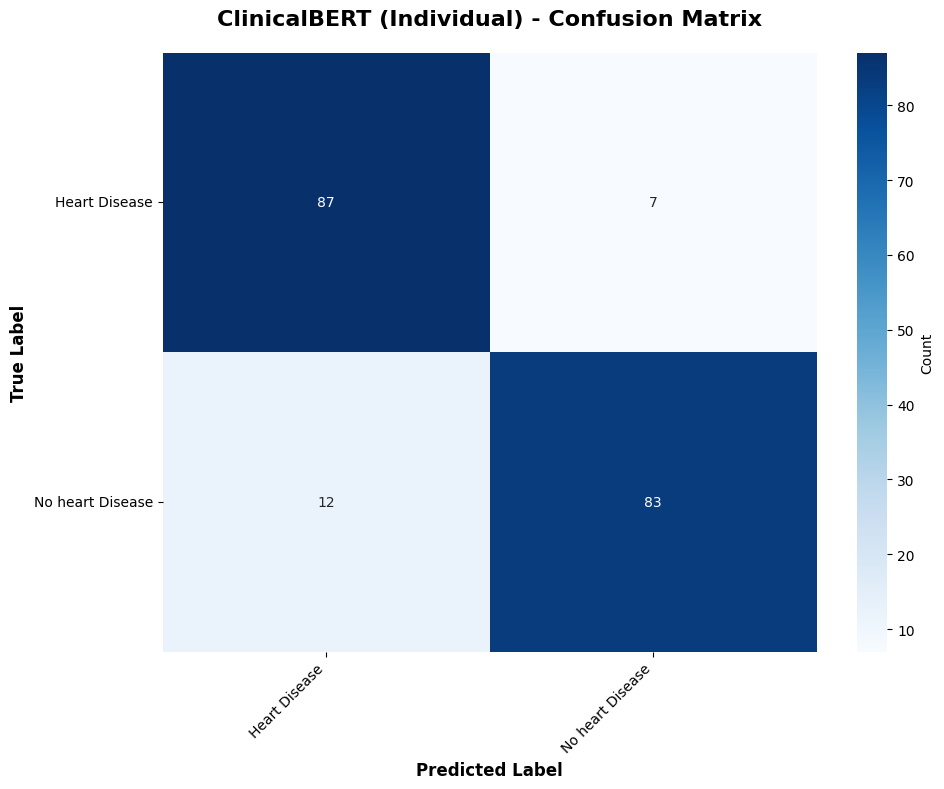


✅ All confusion matrices generated!

PERFORMANCE IMPROVEMENT ANALYSIS

📊 Late Fusion (Averaging) vs Individual Models:
   DistilBERT F1:         0.8783
   ClinicalBERT F1:       0.8994
   Average Individual F1: 0.8888
   Late Fusion (Avg) F1:  0.9100
   Improvement:           +0.0212 (+2.38%)

📊 Late Fusion (Voting) vs Individual Models:
   Average Individual F1: 0.8888
   Late Fusion (Vote) F1: 0.8783
   Improvement:           -0.0105 (-1.19%)

📊 Early Fusion vs Late Fusion (Best):
   Early Fusion F1:            0.8995
   Late Fusion (Averaging) F1: 0.9100
   Difference:                 +0.0105 (+1.17%)

📊 Best Individual vs Best Fusion:
   Best Individual (ClinicalBERT): 0.8994
   Best Fusion (Late Fusion (Averaging)):     0.9100
   Improvement:                           +0.0106 (+1.18%)

✅ COMPREHENSIVE EVALUATION COMPLETED SUCCESSFULLY!

📊 Summary:
   - Total models evaluated: 5
   - Best overall model: Late Fusion (Averaging)
   - Best F1 score: 0.9100
   - All results saved to: 

In [21]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ========== EVALUATION FUNCTIONS ==========

def evaluate_early_fusion_model(model, dataset, device, batch_size=16):
    """
    Evaluate the early fusion model and return predictions and true labels
    """
    model.eval()
    
    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=simple_collate_fn,
        num_workers=0
    )
    
    all_predictions = []
    all_labels = []
    
    print("Evaluating Early Fusion model...")
    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            # Move batch to device
            bert_input_ids = batch['bert_input_ids'].to(device)
            bert_attention_mask = batch['bert_attention_mask'].to(device)
            clinicalbert_input_ids = batch['clinicalbert_input_ids'].to(device)
            clinicalbert_attention_mask = batch['clinicalbert_attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            # Get model predictions
            outputs = model(
                bert_input_ids=bert_input_ids,
                bert_attention_mask=bert_attention_mask,
                clinicalbert_input_ids=clinicalbert_input_ids,
                clinicalbert_attention_mask=clinicalbert_attention_mask
            )
            
            # Get predicted class
            predictions = torch.argmax(outputs.logits, dim=1)
            
            # Store predictions and labels
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            if (batch_idx + 1) % 10 == 0:
                print(f"  Processed {batch_idx + 1}/{len(dataloader)} batches")
    
    return np.array(all_predictions), np.array(all_labels)


def get_model_predictions(model, dataloader, device):
    """
    Get predictions and probabilities from a single model
    """
    model.eval()
    all_predictions = []
    all_probabilities = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            # Move inputs to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            # Get model outputs
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            
            # Get probabilities
            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(logits, dim=1)
            
            # Store results
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return (
        np.array(all_predictions), 
        np.array(all_probabilities),
        np.array(all_labels)
    )


def evaluate_late_fusion_model(
    distilbert_model, 
    clinicalbert_model,
    bert_dataset,
    clinicalbert_dataset,
    device,
    batch_size=16,
    fusion_method='average'
):
    """
    Evaluate Late Fusion model by combining predictions from both models
    """
    print(f"Evaluating Late Fusion model ({fusion_method})...")
    
    # Create dataloaders
    bert_dataloader = DataLoader(
        bert_dataset,
        batch_size=batch_size,
        shuffle=False
    )
    
    clinicalbert_dataloader = DataLoader(
        clinicalbert_dataset,
        batch_size=batch_size,
        shuffle=False
    )
    
    # Get predictions from DistilBERT
    print("  Getting DistilBERT predictions...")
    bert_preds, bert_probs, true_labels = get_model_predictions(
        distilbert_model, 
        bert_dataloader, 
        device
    )
    
    # Get predictions from ClinicalBERT
    print("  Getting ClinicalBERT predictions...")
    clinicalbert_preds, clinicalbert_probs, _ = get_model_predictions(
        clinicalbert_model, 
        clinicalbert_dataloader, 
        device
    )
    
    # Combine predictions based on fusion method
    if fusion_method == 'average':
        # Average the probabilities
        avg_probs = (bert_probs + clinicalbert_probs) / 2
        final_predictions = np.argmax(avg_probs, axis=1)
        
    elif fusion_method == 'voting':
        # Majority voting
        final_predictions = []
        for bert_pred, clinicalbert_pred in zip(bert_preds, clinicalbert_preds):
            if bert_pred == clinicalbert_pred:
                final_predictions.append(bert_pred)
            else:
                # Use DistilBERT prediction in case of disagreement
                final_predictions.append(bert_pred)
        final_predictions = np.array(final_predictions)
    
    return final_predictions, true_labels


def calculate_all_metrics(y_true, y_pred, model_name):
    """
    Calculate all evaluation metrics for a model
    """
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1 (Weighted)': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Precision (Weighted)': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall (Weighted)': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "Cohen's Kappa": cohen_kappa_score(y_true, y_pred),
        'Matthews Corr Coeff': matthews_corrcoef(y_true, y_pred)
    }
    
    return metrics


def plot_metrics_comparison(results_df, title='Model Performance Comparison'):
    """
    Create a bar plot comparing all models across all metrics
    """
    # Set up the plot
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(title, fontsize=18, fontweight='bold', y=1.00)
    
    metrics = ['Accuracy', 'F1 (Weighted)', 'Precision (Weighted)', 
               'Recall (Weighted)', "Cohen's Kappa", 'Matthews Corr Coeff']
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for idx, (ax, metric) in enumerate(zip(axes.flatten(), metrics)):
        # Create bar plot
        bars = ax.bar(
            range(len(results_df)), 
            results_df[metric], 
            color=colors[:len(results_df)],
            alpha=0.8,
            edgecolor='black',
            linewidth=1.5
        )
        
        # Customize plot
        ax.set_title(metric, fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel('Score', fontsize=11)
        ax.set_xticks(range(len(results_df)))
        ax.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=10)
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2., 
                height,
                f'{height:.4f}',
                ha='center', 
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )
        
        # Highlight best performance
        best_idx = results_df[metric].idxmax()
        bars[best_idx].set_edgecolor('gold')
        bars[best_idx].set_linewidth(3)
    
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, class_names, title='Confusion Matrix', figsize=(10, 8)):
    """
    Plot confusion matrix
    """
    plt.figure(figsize=figsize)
    
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Count'}
    )
    
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ========== MAIN EVALUATION SCRIPT ==========

print("="*100)
print("COMPREHENSIVE MODEL EVALUATION - EARLY FUSION vs LATE FUSION")
print("="*100)

# Get class names
class_names = label_encoder.classes_
num_labels = len(class_names)

print(f"\n📋 Dataset Info:")
print(f"   Number of classes: {num_labels}")
print(f"   Classes: {', '.join(class_names)}")
print(f"   Validation samples: {len(val_dataset)}")

# Store all results
all_results = []

# ========== 1. EVALUATE EARLY FUSION MODEL ==========
print("\n" + "="*100)
print("1. EVALUATING EARLY FUSION MODEL")
print("="*100)

y_pred_early, y_true_early = evaluate_early_fusion_model(
    early_fusion_model, 
    val_dataset, 
    device,
    batch_size=16
)

print(f"✅ Early Fusion evaluation complete!")

# Calculate metrics for Early Fusion
early_fusion_metrics = calculate_all_metrics(
    y_true_early, 
    y_pred_early, 
    'Early Fusion'
)
all_results.append(early_fusion_metrics)

# Confusion matrix for Early Fusion
cm_early = confusion_matrix(y_true_early, y_pred_early)

# ========== 2. LOAD LATE FUSION MODELS ==========
print("\n" + "="*100)
print("2. LOADING LATE FUSION MODELS")
print("="*100)

print("📥 Loading trained individual models...")
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    "./distilbert_individual"
).to(device)
clinicalbert_model = AutoModelForSequenceClassification.from_pretrained(
    "./clinicalbert_individual"
).to(device)
print("✅ Models loaded successfully!")

# ========== 3. EVALUATE LATE FUSION (PROBABILITY AVERAGING) ==========
print("\n" + "="*100)
print("3. EVALUATING LATE FUSION - PROBABILITY AVERAGING")
print("="*100)

y_pred_late_avg, y_true_late = evaluate_late_fusion_model(
    distilbert_model,
    clinicalbert_model,
    val_dataset_bert,
    val_dataset_clinicalbert,
    device,
    batch_size=16,
    fusion_method='average'
)

print(f"✅ Late Fusion (Averaging) evaluation complete!")

# Calculate metrics for Late Fusion (Averaging)
late_fusion_avg_metrics = calculate_all_metrics(
    y_true_late, 
    y_pred_late_avg, 
    'Late Fusion (Averaging)'
)
all_results.append(late_fusion_avg_metrics)

# Confusion matrix for Late Fusion (Averaging)
cm_late_avg = confusion_matrix(y_true_late, y_pred_late_avg)

# ========== 4. EVALUATE LATE FUSION (MAJORITY VOTING) ==========
print("\n" + "="*100)
print("4. EVALUATING LATE FUSION - MAJORITY VOTING")
print("="*100)

y_pred_late_vote, y_true_late_vote = evaluate_late_fusion_model(
    distilbert_model,
    clinicalbert_model,
    val_dataset_bert,
    val_dataset_clinicalbert,
    device,
    batch_size=16,
    fusion_method='voting'
)

print(f"✅ Late Fusion (Voting) evaluation complete!")

# Calculate metrics for Late Fusion (Voting)
late_fusion_vote_metrics = calculate_all_metrics(
    y_true_late_vote, 
    y_pred_late_vote, 
    'Late Fusion (Voting)'
)
all_results.append(late_fusion_vote_metrics)

# Confusion matrix for Late Fusion (Voting)
cm_late_vote = confusion_matrix(y_true_late_vote, y_pred_late_vote)

# ========== 5. EVALUATE INDIVIDUAL MODELS ==========
print("\n" + "="*100)
print("5. EVALUATING INDIVIDUAL MODELS (FOR REFERENCE)")
print("="*100)

# DistilBERT individual
print("  Evaluating DistilBERT...")
bert_dataloader = DataLoader(val_dataset_bert, batch_size=16, shuffle=False)
y_pred_bert, _, y_true_bert = get_model_predictions(distilbert_model, bert_dataloader, device)
bert_metrics = calculate_all_metrics(y_true_bert, y_pred_bert, 'DistilBERT (Individual)')
all_results.append(bert_metrics)

# Confusion matrix for DistilBERT
cm_bert = confusion_matrix(y_true_bert, y_pred_bert)

# ClinicalBERT individual
print("  Evaluating ClinicalBERT...")
clinicalbert_dataloader = DataLoader(val_dataset_clinicalbert, batch_size=16, shuffle=False)
y_pred_clinicalbert, _, y_true_clinicalbert = get_model_predictions(clinicalbert_model, clinicalbert_dataloader, device)
clinicalbert_metrics = calculate_all_metrics(y_true_clinicalbert, y_pred_clinicalbert, 'ClinicalBERT (Individual)')
all_results.append(clinicalbert_metrics)

# Confusion matrix for ClinicalBERT
cm_clinicalbert = confusion_matrix(y_true_clinicalbert, y_pred_clinicalbert)

print(f"✅ Individual models evaluation complete!")

# ========== 6. CREATE RESULTS DATAFRAME ==========
results_df = pd.DataFrame(all_results)

# Round all numeric columns to 4 decimal places
numeric_cols = ['Accuracy', 'F1 (Weighted)', 'Precision (Weighted)', 
                'Recall (Weighted)', "Cohen's Kappa", 'Matthews Corr Coeff']
results_df[numeric_cols] = results_df[numeric_cols].round(4)

# ========== 7. DISPLAY RESULTS ==========
print("\n" + "="*100)
print("COMPREHENSIVE METRICS COMPARISON")
print("="*100)
print("\n")
print(results_df.to_string(index=False))
print("\n" + "="*100)

# ========== 8. IDENTIFY BEST MODEL ==========
print("\n" + "="*100)
print("BEST MODEL PER METRIC")
print("="*100)

for metric in numeric_cols:
    best_idx = results_df[metric].idxmax()
    best_model = results_df.loc[best_idx, 'Model']
    best_score = results_df.loc[best_idx, metric]
    print(f"🏆 {metric:25s}: {best_model:30s} ({best_score:.4f})")

# Overall best model (based on F1 score)
best_overall_idx = results_df['F1 (Weighted)'].idxmax()
best_overall_model = results_df.loc[best_overall_idx, 'Model']
best_overall_f1 = results_df.loc[best_overall_idx, 'F1 (Weighted)']

print("\n" + "="*100)
print(f"🏆 OVERALL BEST MODEL (Based on F1 Score): {best_overall_model} (F1: {best_overall_f1:.4f})")
print("="*100)

# ========== 9. SAVE RESULTS TO CSV ==========
results_df.to_csv('model_comparison_results.csv', index=False)
print("\n💾 Results saved to 'model_comparison_results.csv'")

# ========== 10. DETAILED CLASSIFICATION REPORTS ==========
print("\n" + "="*100)
print("DETAILED CLASSIFICATION REPORTS - ALL MODELS")
print("="*100)

print("\n" + "-"*100)
print("1. EARLY FUSION MODEL")
print("-"*100)
print(classification_report(y_true_early, y_pred_early, target_names=class_names, digits=4))

print("\n" + "-"*100)
print("2. LATE FUSION (PROBABILITY AVERAGING)")
print("-"*100)
print(classification_report(y_true_late, y_pred_late_avg, target_names=class_names, digits=4))

print("\n" + "-"*100)
print("3. LATE FUSION (MAJORITY VOTING)")
print("-"*100)
print(classification_report(y_true_late_vote, y_pred_late_vote, target_names=class_names, digits=4))

print("\n" + "-"*100)
print("4. DISTILBERT (INDIVIDUAL)")
print("-"*100)
print(classification_report(y_true_bert, y_pred_bert, target_names=class_names, digits=4))

print("\n" + "-"*100)
print("5. CLINICALBERT (INDIVIDUAL)")
print("-"*100)
print(classification_report(y_true_clinicalbert, y_pred_clinicalbert, target_names=class_names, digits=4))

print("\n" + "="*100)

# ========== 11. VISUALIZATIONS ==========
print("\n📈 Generating visualization plots...")

# Plot metrics comparison
plot_metrics_comparison(results_df, title='Model Performance Comparison - All Metrics')

# Plot confusion matrices for ALL models
print("\n📊 Generating confusion matrices for all models...")

print("\n  → Plotting Early Fusion confusion matrix...")
plot_confusion_matrix(
    cm_early, 
    class_names, 
    title='Early Fusion - Confusion Matrix'
)

print("  → Plotting Late Fusion (Averaging) confusion matrix...")
plot_confusion_matrix(
    cm_late_avg, 
    class_names, 
    title='Late Fusion (Probability Averaging) - Confusion Matrix'
)

print("  → Plotting Late Fusion (Voting) confusion matrix...")
plot_confusion_matrix(
    cm_late_vote, 
    class_names, 
    title='Late Fusion (Majority Voting) - Confusion Matrix'
)

print("  → Plotting DistilBERT (Individual) confusion matrix...")
plot_confusion_matrix(
    cm_bert, 
    class_names, 
    title='DistilBERT (Individual) - Confusion Matrix'
)

print("  → Plotting ClinicalBERT (Individual) confusion matrix...")
plot_confusion_matrix(
    cm_clinicalbert, 
    class_names, 
    title='ClinicalBERT (Individual) - Confusion Matrix'
)

print("\n✅ All confusion matrices generated!")

# ========== 12. PERFORMANCE IMPROVEMENT ANALYSIS ==========
print("\n" + "="*100)
print("PERFORMANCE IMPROVEMENT ANALYSIS")
print("="*100)

# Compare Late Fusion vs Individual models
bert_f1 = results_df[results_df['Model'] == 'DistilBERT (Individual)']['F1 (Weighted)'].values[0]
clinicalbert_f1 = results_df[results_df['Model'] == 'ClinicalBERT (Individual)']['F1 (Weighted)'].values[0]
late_avg_f1 = results_df[results_df['Model'] == 'Late Fusion (Averaging)']['F1 (Weighted)'].values[0]
late_vote_f1 = results_df[results_df['Model'] == 'Late Fusion (Voting)']['F1 (Weighted)'].values[0]
early_f1 = results_df[results_df['Model'] == 'Early Fusion']['F1 (Weighted)'].values[0]

avg_individual_f1 = (bert_f1 + clinicalbert_f1) / 2

print(f"\n📊 Late Fusion (Averaging) vs Individual Models:")
print(f"   DistilBERT F1:         {bert_f1:.4f}")
print(f"   ClinicalBERT F1:       {clinicalbert_f1:.4f}")
print(f"   Average Individual F1: {avg_individual_f1:.4f}")
print(f"   Late Fusion (Avg) F1:  {late_avg_f1:.4f}")
print(f"   Improvement:           {late_avg_f1 - avg_individual_f1:+.4f} ({((late_avg_f1 - avg_individual_f1) / avg_individual_f1 * 100):+.2f}%)")

print(f"\n📊 Late Fusion (Voting) vs Individual Models:")
print(f"   Average Individual F1: {avg_individual_f1:.4f}")
print(f"   Late Fusion (Vote) F1: {late_vote_f1:.4f}")
print(f"   Improvement:           {late_vote_f1 - avg_individual_f1:+.4f} ({((late_vote_f1 - avg_individual_f1) / avg_individual_f1 * 100):+.2f}%)")

print(f"\n📊 Early Fusion vs Late Fusion (Best):")
best_late_f1 = max(late_avg_f1, late_vote_f1)
best_late_method = "Averaging" if late_avg_f1 > late_vote_f1 else "Voting"
print(f"   Early Fusion F1:            {early_f1:.4f}")
print(f"   Late Fusion ({best_late_method}) F1: {best_late_f1:.4f}")
print(f"   Difference:                 {best_late_f1 - early_f1:+.4f} ({((best_late_f1 - early_f1) / early_f1 * 100):+.2f}%)")

print(f"\n📊 Best Individual vs Best Fusion:")
best_individual_f1 = max(bert_f1, clinicalbert_f1)
best_individual_name = "ClinicalBERT" if clinicalbert_f1 > bert_f1 else "DistilBERT"
best_fusion_f1 = max(early_f1, late_avg_f1, late_vote_f1)
if best_fusion_f1 == early_f1:
    best_fusion_name = "Early Fusion"
elif best_fusion_f1 == late_avg_f1:
    best_fusion_name = "Late Fusion (Averaging)"
else:
    best_fusion_name = "Late Fusion (Voting)"

print(f"   Best Individual ({best_individual_name}): {best_individual_f1:.4f}")
print(f"   Best Fusion ({best_fusion_name}):     {best_fusion_f1:.4f}")
print(f"   Improvement:                           {best_fusion_f1 - best_individual_f1:+.4f} ({((best_fusion_f1 - best_individual_f1) / best_individual_f1 * 100):+.2f}%)")

print("\n" + "="*100)
print("✅ COMPREHENSIVE EVALUATION COMPLETED SUCCESSFULLY!")
print("="*100)
print("\n📊 Summary:")
print(f"   - Total models evaluated: 5")
print(f"   - Best overall model: {best_overall_model}")
print(f"   - Best F1 score: {best_overall_f1:.4f}")
print(f"   - All results saved to: model_comparison_results.csv")
print("="*100)

GENERATING ROC AND PR CURVES

📊 Getting probabilities for Early Fusion...
📊 Getting probabilities for Late Fusion (Averaging)...
📊 Getting probabilities for Late Fusion (Voting)...
📊 Getting probabilities for DistilBERT...
📊 Getting probabilities for ClinicalBERT...
✅ All probabilities collected!

PLOTTING ROC AND PR CURVES

📈 Plotting combined ROC curves...


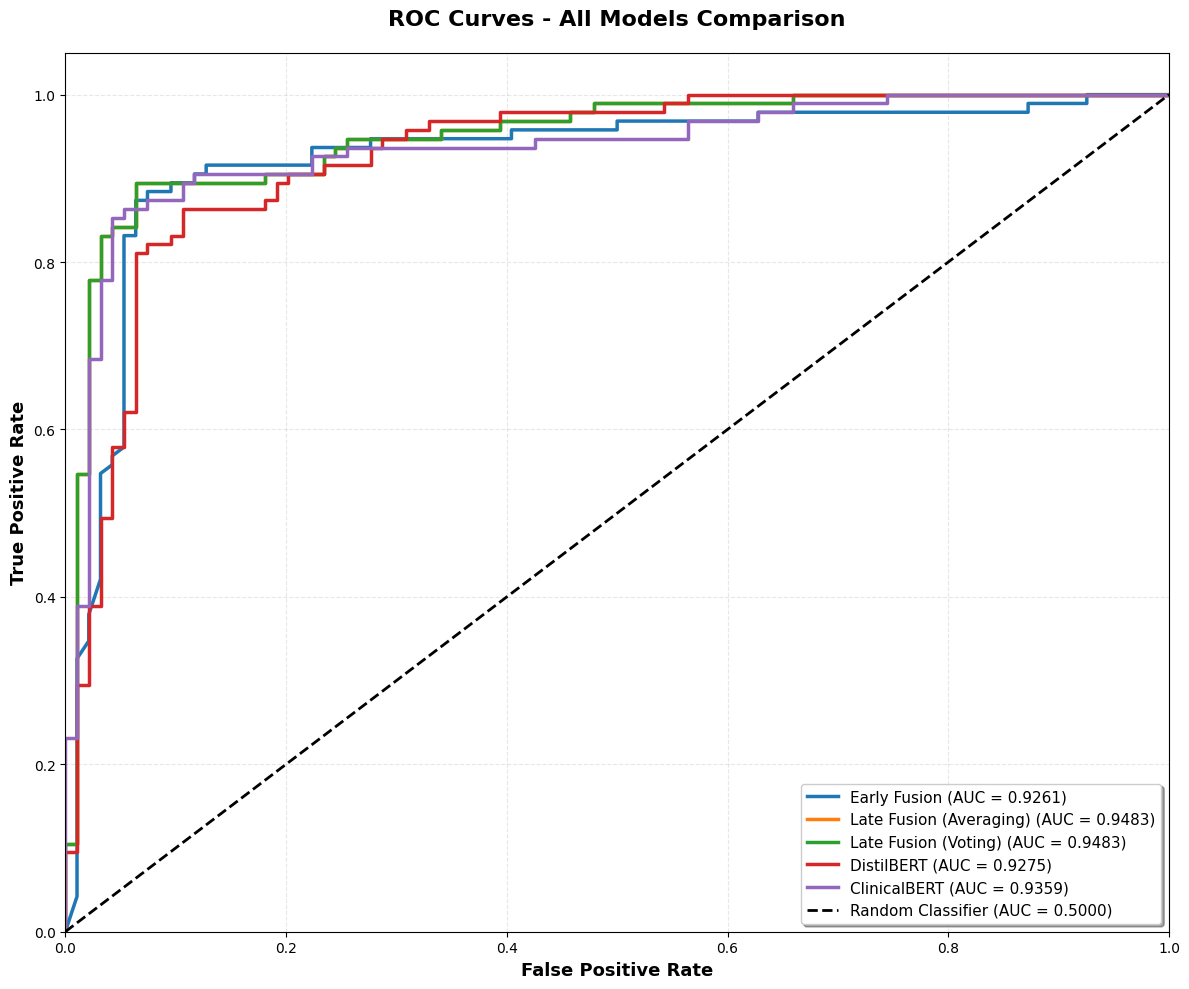

📈 Plotting combined PR curves...


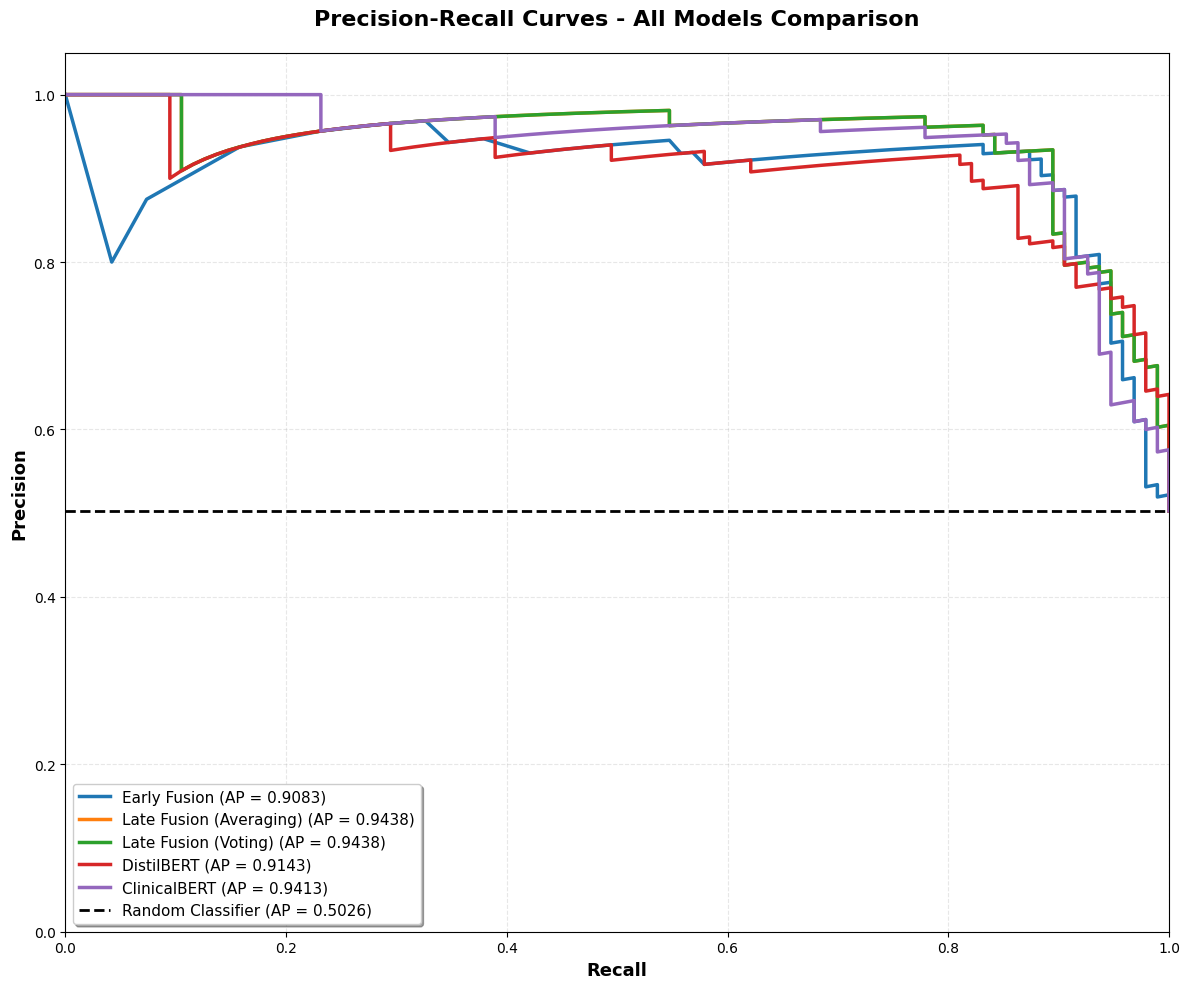

📈 Plotting individual ROC curves...


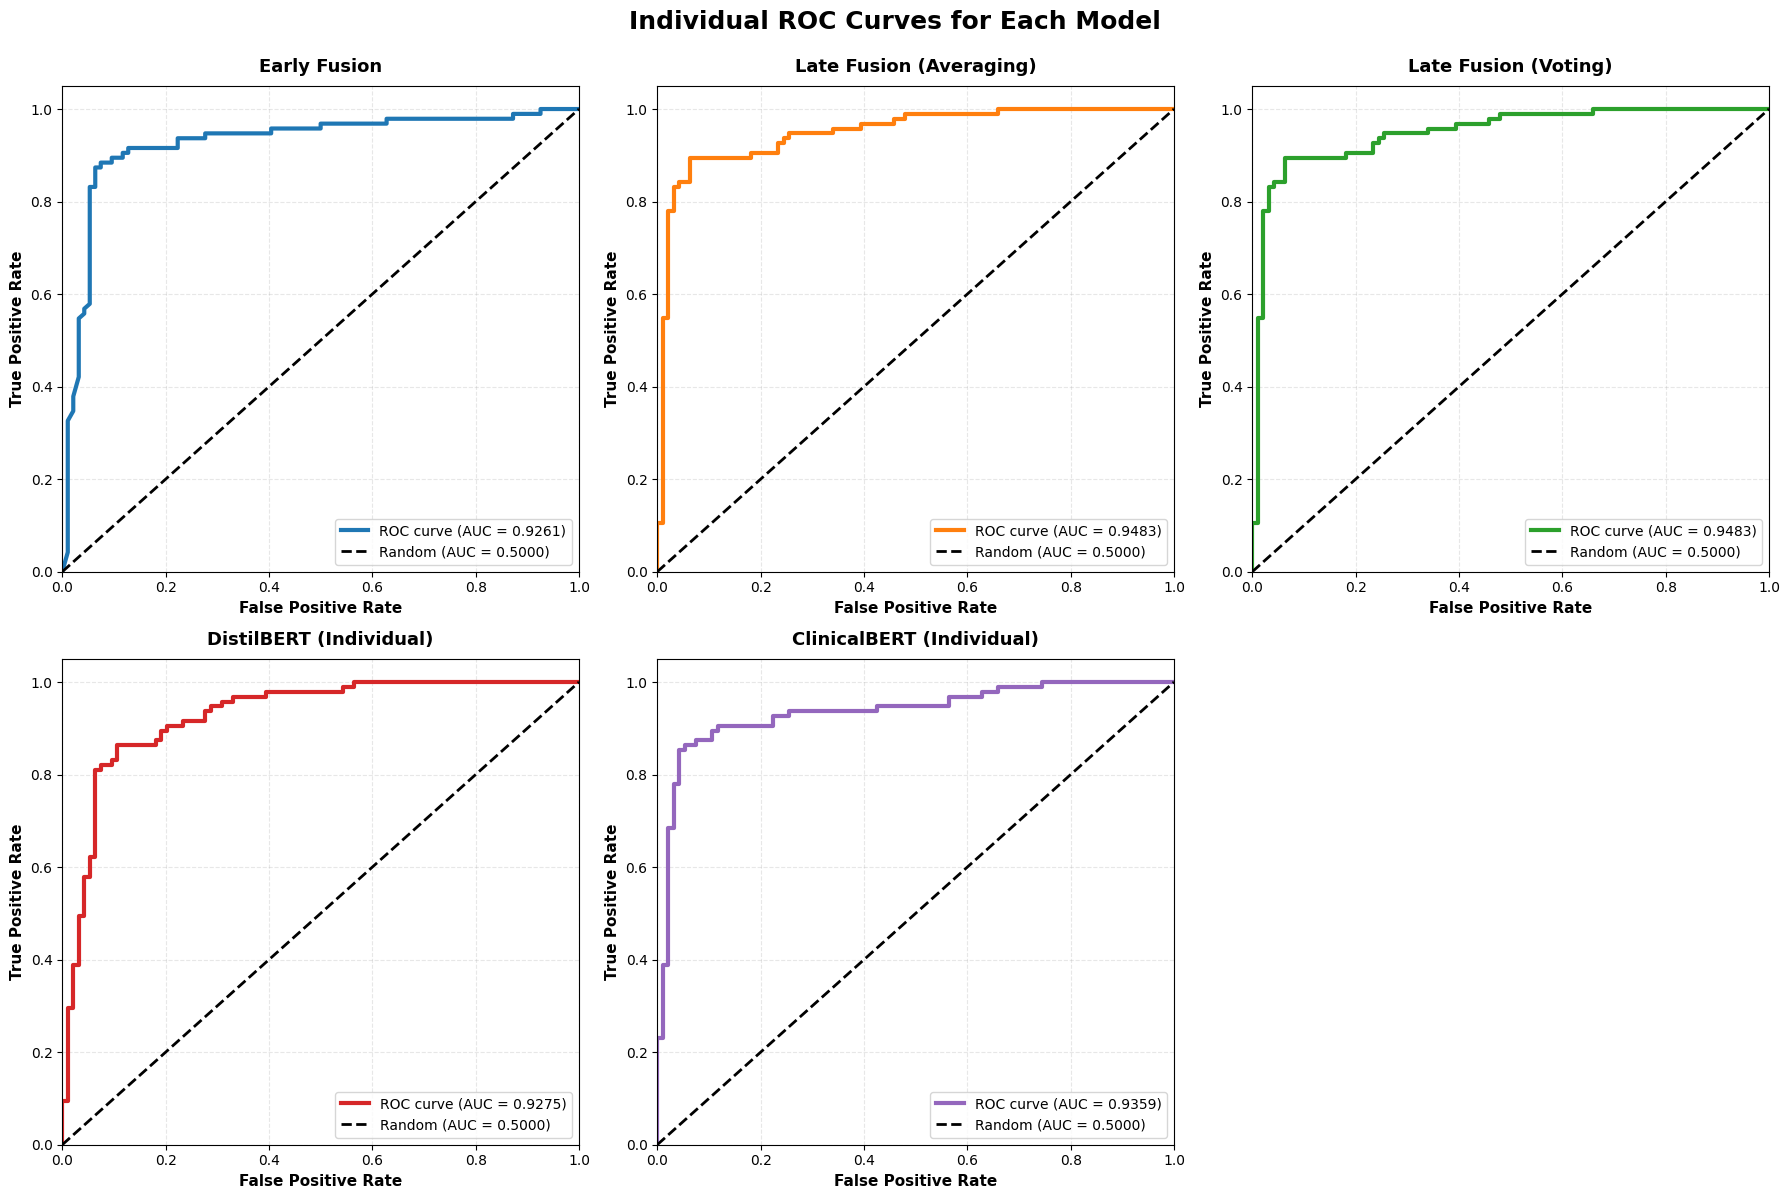

📈 Plotting individual PR curves...


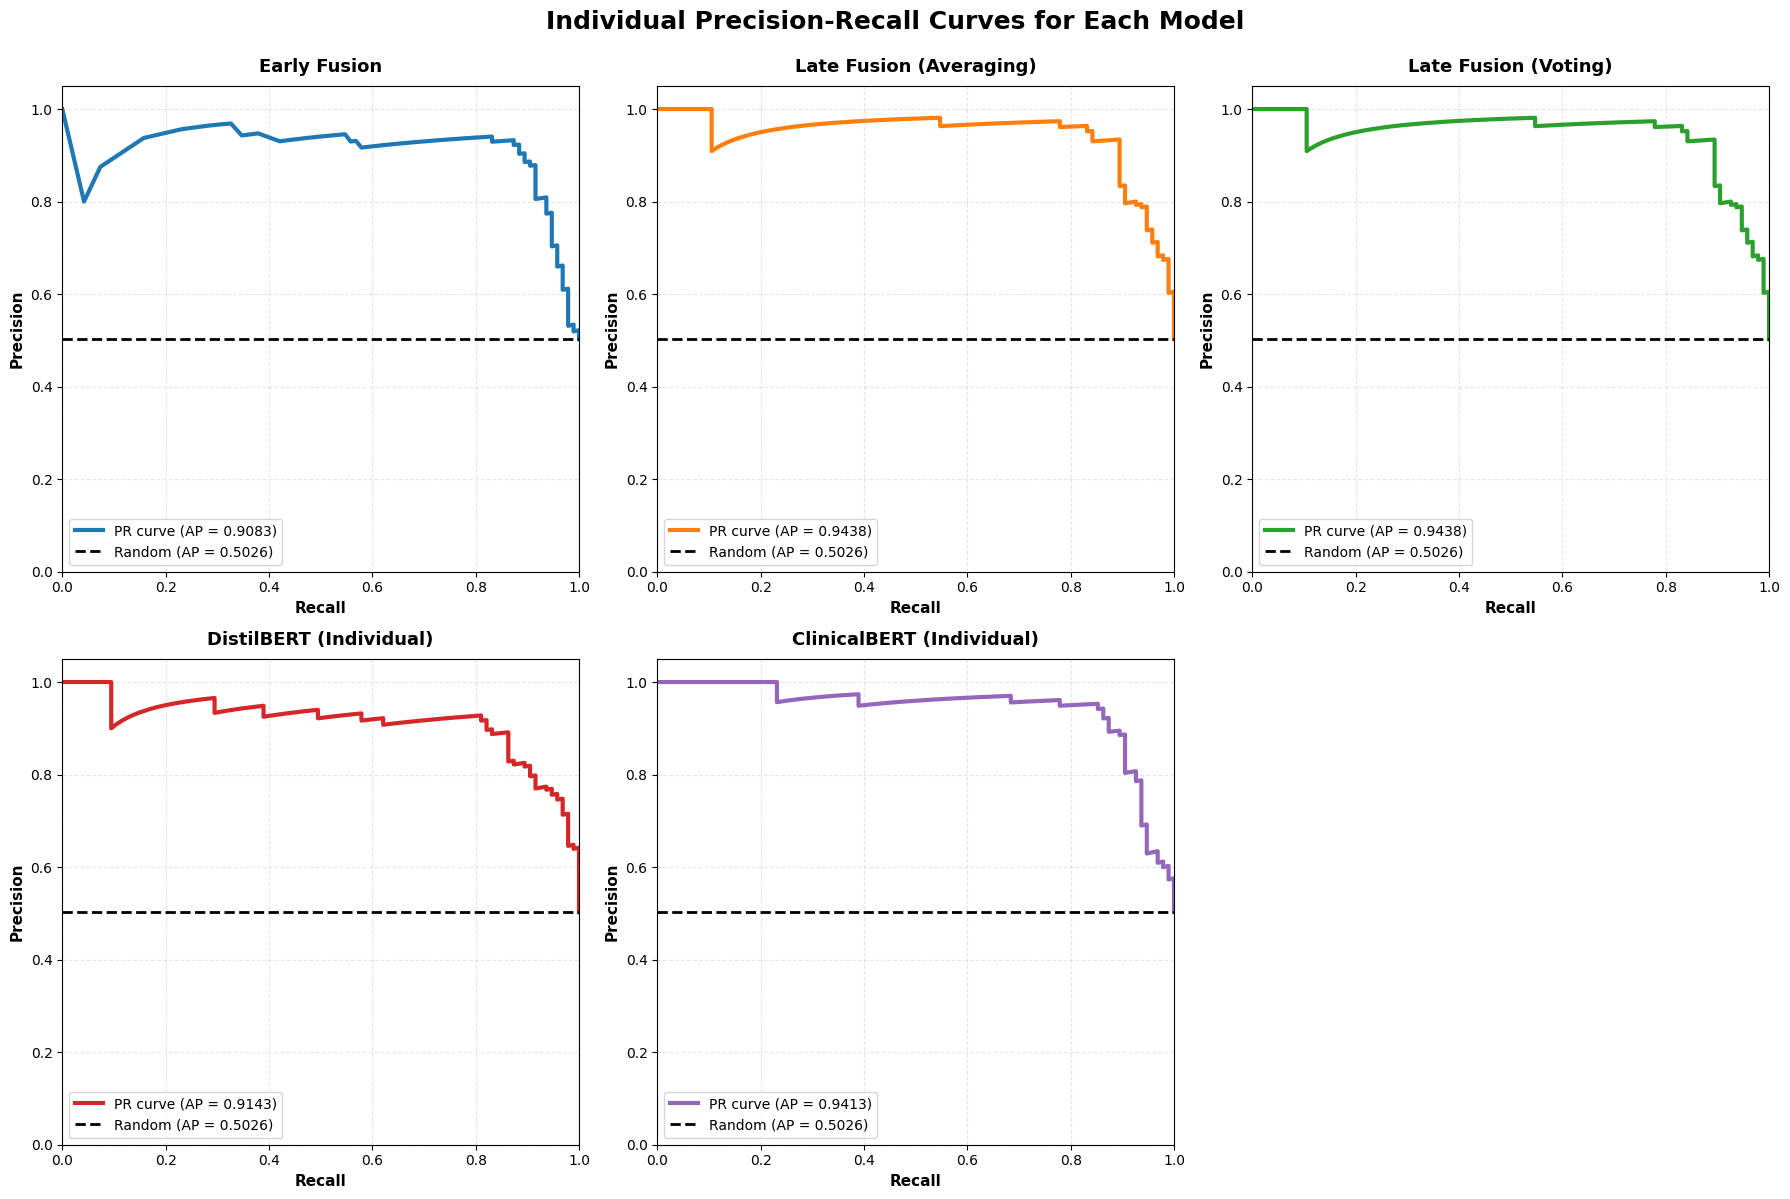


✅ All ROC and PR curve plots generated successfully!


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# ========== FUNCTION TO GET PROBABILITIES ==========

def get_early_fusion_probabilities(model, dataset, device, batch_size=16):
    """Get probabilities from early fusion model"""
    model.eval()
    
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=simple_collate_fn,
        num_workers=0
    )
    
    all_probabilities = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            bert_input_ids = batch['bert_input_ids'].to(device)
            bert_attention_mask = batch['bert_attention_mask'].to(device)
            clinicalbert_input_ids = batch['clinicalbert_input_ids'].to(device)
            clinicalbert_attention_mask = batch['clinicalbert_attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                bert_input_ids=bert_input_ids,
                bert_attention_mask=bert_attention_mask,
                clinicalbert_input_ids=clinicalbert_input_ids,
                clinicalbert_attention_mask=clinicalbert_attention_mask
            )
            
            probabilities = torch.softmax(outputs.logits, dim=1)
            all_probabilities.extend(probabilities.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_probabilities), np.array(all_labels)


def get_late_fusion_probabilities(
    distilbert_model,
    clinicalbert_model,
    bert_dataset,
    clinicalbert_dataset,
    device,
    batch_size=16,
    fusion_method='average'
):
    """Get probabilities from late fusion model"""
    
    bert_dataloader = DataLoader(bert_dataset, batch_size=batch_size, shuffle=False)
    clinicalbert_dataloader = DataLoader(clinicalbert_dataset, batch_size=batch_size, shuffle=False)
    
    # Get predictions from both models
    bert_preds, bert_probs, true_labels = get_model_predictions(
        distilbert_model, bert_dataloader, device
    )
    clinicalbert_preds, clinicalbert_probs, _ = get_model_predictions(
        clinicalbert_model, clinicalbert_dataloader, device
    )
    
    if fusion_method == 'average':
        avg_probs = (bert_probs + clinicalbert_probs) / 2
        return avg_probs, true_labels
    elif fusion_method == 'voting':
        avg_probs = (bert_probs + clinicalbert_probs) / 2
        return avg_probs, true_labels
    
    return avg_probs, true_labels


# ========== GET PROBABILITIES FOR ALL MODELS ==========

print("="*100)
print("GENERATING ROC AND PR CURVES")
print("="*100)

# Early Fusion
print("\n📊 Getting probabilities for Early Fusion...")
early_probs, early_labels = get_early_fusion_probabilities(early_fusion_model, val_dataset, device)

# Late Fusion (Averaging)
print("📊 Getting probabilities for Late Fusion (Averaging)...")
late_avg_probs, late_avg_labels = get_late_fusion_probabilities(
    distilbert_model, clinicalbert_model,
    val_dataset_bert, val_dataset_clinicalbert,
    device, fusion_method='average'
)

# Late Fusion (Voting)
print("📊 Getting probabilities for Late Fusion (Voting)...")
late_vote_probs, late_vote_labels = get_late_fusion_probabilities(
    distilbert_model, clinicalbert_model,
    val_dataset_bert, val_dataset_clinicalbert,
    device, fusion_method='voting'
)

# Individual DistilBERT
print("📊 Getting probabilities for DistilBERT...")
bert_dataloader = DataLoader(val_dataset_bert, batch_size=16, shuffle=False)
_, bert_probs, bert_labels = get_model_predictions(distilbert_model, bert_dataloader, device)

# Individual ClinicalBERT
print("📊 Getting probabilities for ClinicalBERT...")
clinicalbert_dataloader = DataLoader(val_dataset_clinicalbert, batch_size=16, shuffle=False)
_, clinicalbert_probs, clinicalbert_labels = get_model_predictions(clinicalbert_model, clinicalbert_dataloader, device)

print("✅ All probabilities collected!")


# ========== PLOT ROC CURVES ==========

def plot_roc_curves_all_models():
    """Plot ROC curves for all models on one figure"""
    
    plt.figure(figsize=(12, 10))
    
    models_data = [
        ('Early Fusion', early_probs, early_labels, '#1f77b4'),
        ('Late Fusion (Averaging)', late_avg_probs, late_avg_labels, '#ff7f0e'),
        ('Late Fusion (Voting)', late_vote_probs, late_vote_labels, '#2ca02c'),
        ('DistilBERT', bert_probs, bert_labels, '#d62728'),
        ('ClinicalBERT', clinicalbert_probs, clinicalbert_labels, '#9467bd')
    ]
    
    for model_name, probs, labels, color in models_data:
        # For binary classification, use probabilities of positive class
        y_score = probs[:, 1]
        
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(labels, y_score)
        roc_auc = auc(fpr, tpr)
        
        # Plot
        plt.plot(fpr, tpr, color=color, lw=2.5, 
                label=f'{model_name} (AUC = {roc_auc:.4f})')
    
    # Plot diagonal line
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.5000)')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
    plt.title('ROC Curves - All Models Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()


def plot_pr_curves_all_models():
    """Plot Precision-Recall curves for all models on one figure"""
    
    plt.figure(figsize=(12, 10))
    
    models_data = [
        ('Early Fusion', early_probs, early_labels, '#1f77b4'),
        ('Late Fusion (Averaging)', late_avg_probs, late_avg_labels, '#ff7f0e'),
        ('Late Fusion (Voting)', late_vote_probs, late_vote_labels, '#2ca02c'),
        ('DistilBERT', bert_probs, bert_labels, '#d62728'),
        ('ClinicalBERT', clinicalbert_probs, clinicalbert_labels, '#9467bd')
    ]
    
    for model_name, probs, labels, color in models_data:
        # For binary classification, use probabilities of positive class
        y_score = probs[:, 1]
        
        # Calculate PR curve
        precision, recall, _ = precision_recall_curve(labels, y_score)
        avg_precision = average_precision_score(labels, y_score)
        
        # Plot
        plt.plot(recall, precision, color=color, lw=2.5,
                label=f'{model_name} (AP = {avg_precision:.4f})')
    
    # Calculate baseline (random classifier)
    baseline = np.sum(early_labels) / len(early_labels)
    plt.plot([0, 1], [baseline, baseline], 'k--', lw=2, 
            label=f'Random Classifier (AP = {baseline:.4f})')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=13, fontweight='bold')
    plt.ylabel('Precision', fontsize=13, fontweight='bold')
    plt.title('Precision-Recall Curves - All Models Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.legend(loc="lower left", fontsize=11, frameon=True, shadow=True)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()


def plot_individual_roc_curves():
    """Plot individual ROC curves for each model"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Individual ROC Curves for Each Model', fontsize=18, fontweight='bold', y=0.995)
    
    models_data = [
        ('Early Fusion', early_probs, early_labels, '#1f77b4'),
        ('Late Fusion (Averaging)', late_avg_probs, late_avg_labels, '#ff7f0e'),
        ('Late Fusion (Voting)', late_vote_probs, late_vote_labels, '#2ca02c'),
        ('DistilBERT (Individual)', bert_probs, bert_labels, '#d62728'),
        ('ClinicalBERT (Individual)', clinicalbert_probs, clinicalbert_labels, '#9467bd')
    ]
    
    for idx, (ax, (model_name, probs, labels, color)) in enumerate(zip(axes.flatten(), models_data)):
        y_score = probs[:, 1]
        fpr, tpr, _ = roc_curve(labels, y_score)
        roc_auc = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, color=color, lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
        ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.5000)')
        
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
        ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
        ax.set_title(model_name, fontsize=13, fontweight='bold', pad=10)
        ax.legend(loc="lower right", fontsize=10)
        ax.grid(True, alpha=0.3, linestyle='--')
    
    # Hide the 6th subplot
    axes.flatten()[5].axis('off')
    
    plt.tight_layout()
    plt.show()


def plot_individual_pr_curves():
    """Plot individual PR curves for each model"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Individual Precision-Recall Curves for Each Model', 
                fontsize=18, fontweight='bold', y=0.995)
    
    models_data = [
        ('Early Fusion', early_probs, early_labels, '#1f77b4'),
        ('Late Fusion (Averaging)', late_avg_probs, late_avg_labels, '#ff7f0e'),
        ('Late Fusion (Voting)', late_vote_probs, late_vote_labels, '#2ca02c'),
        ('DistilBERT (Individual)', bert_probs, bert_labels, '#d62728'),
        ('ClinicalBERT (Individual)', clinicalbert_probs, clinicalbert_labels, '#9467bd')
    ]
    
    baseline = np.sum(early_labels) / len(early_labels)
    
    for idx, (ax, (model_name, probs, labels, color)) in enumerate(zip(axes.flatten(), models_data)):
        y_score = probs[:, 1]
        precision, recall, _ = precision_recall_curve(labels, y_score)
        avg_precision = average_precision_score(labels, y_score)
        
        ax.plot(recall, precision, color=color, lw=3, 
               label=f'PR curve (AP = {avg_precision:.4f})')
        ax.plot([0, 1], [baseline, baseline], 'k--', lw=2, 
               label=f'Random (AP = {baseline:.4f})')
        
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('Recall', fontsize=11, fontweight='bold')
        ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
        ax.set_title(model_name, fontsize=13, fontweight='bold', pad=10)
        ax.legend(loc="lower left", fontsize=10)
        ax.grid(True, alpha=0.3, linestyle='--')
    
    # Hide the 6th subplot
    axes.flatten()[5].axis('off')
    
    plt.tight_layout()
    plt.show()


# ========== GENERATE ALL PLOTS ==========

print("\n" + "="*100)
print("PLOTTING ROC AND PR CURVES")
print("="*100)

print("\n📈 Plotting combined ROC curves...")
plot_roc_curves_all_models()

print("📈 Plotting combined PR curves...")
plot_pr_curves_all_models()

print("📈 Plotting individual ROC curves...")
plot_individual_roc_curves()

print("📈 Plotting individual PR curves...")
plot_individual_pr_curves()

print("\n✅ All ROC and PR curve plots generated successfully!")
print("="*100)